In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Simple machine learning Models 

# l'objectif de ce tp d'apprendre a contruire un model de machine learning simple 

In [23]:
import pandas as pd 
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression

In [6]:
df=pd.read_csv('/kaggle/input/datasets/mohithsairamreddy/salary-data/Salary_Data.csv')
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0
6700,32.0,Male,High School,Sales Associate,3.0,50000.0
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0


### se renseigner sur la data frame 

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


faire RangeIndex moins(-) Non-Null Count  pour trouver le nombre de case vide par colone.
ca donne le resultat suivant a l'aide de isna().sum()

In [8]:
# Dimensions du tableau : (nombre de lignes, nombre de colonnes)
print(df.shape)

# Nombre de valeurs manquantes par colonne
print(df.isna().sum())

# Aperçu des 5 premières lignes
df.head()

(6704, 6)
Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


# NB : matplotlib ne fonctionne que avec des valeur numerque nous allons donc reduire la data frame uniquement a la variable d'entre X et la variable cible y 


### nettoyage et extraction de X et y

In [16]:
# Suppression des lignes où l'expérience ou le salaire est vide
df = df.dropna(subset=["Years of Experience", "Salary"])

# Variable d'entrée (feature) : années d'expérience, en tableau 2D
X = df[["Years of Experience"]].values

# Variable de sortie (cible) : salaire, en tableau 1D
Y = df["Salary"].values

# Vérification des dimensions et aperçu
print(X.shape, y.shape)
print(X[:5])
print(y[:5])

(6699, 1) (6699,)
[[ 5.]
 [ 3.]
 [15.]
 [ 7.]
 [20.]]
[ 90000.  65000. 150000.  60000. 200000.]


### découpage du dataframe en train et test

In [18]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size =.2,random_state =3)
# Vérification des tailles
print(X_train.shape, X_test.shape)
print(Y_train.shape, Y_test.shape)

(5359, 1) (1340, 1)
(5359,) (1340,)


### nuage de points afin de verifier quel probleme de machine learning nous souhaitons resoudre ce qui favorise le choix du bon algorithme de machine learning 

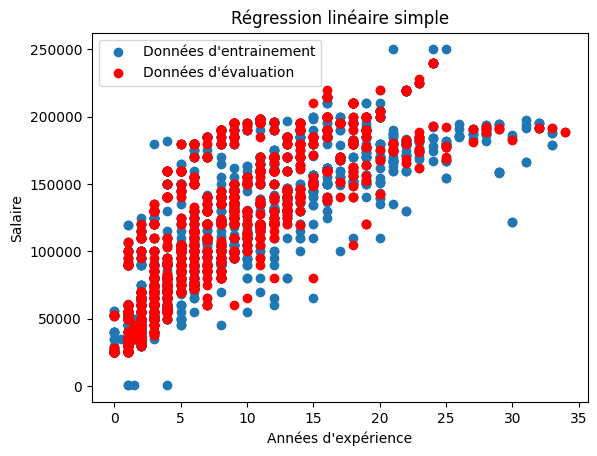

In [22]:
# Points des données d'entraînement
plt.scatter(X_train, Y_train, label="Données d'entrainement")

# Points des données d'évaluation, en rouge pour les distinguer
plt.scatter(X_test, Y_test, label="Données d'évaluation", color="r")

# Nom de l'axe horizontal
plt.xlabel("Années d'expérience")

# Nom de l'axe vertical
plt.ylabel("Salaire")

# Titre du graphique
plt.title("Régression linéaire simple")

# Affichage de la légende (utilise les label définis plus haut)
plt.legend()

# Affichage du graphique
plt.show()

### on remarque que les données sont repartie de sorte a representer une droite , on peut donc dire qu'il s'agit d'un probleme de regression lineaire

### entraînement du modèle

In [24]:
# Création du modèle (vide, pas encore entraîné)
reg = LinearRegression()

# Entraînement sur les données d'apprentissage uniquement
reg.fit(X_train, Y_train);

# Paramètres appris : pente a et ordonnée à l'origine b
print(reg.coef_, reg.intercept_)

[7079.20738381] 57736.6631157268


### prédiction sur les données de test

In [25]:
# Prédiction des salaires à partir des expériences du jeu de test
Y_pred = reg.predict(X_test)

# Tableau comparatif des 10 premières lignes : réel, prédit, écart
comparaison = pd.DataFrame({
    "Réel": Y_test[:10],
    "Prédit": Y_pred[:10].round(0),
    "Écart": (Y_pred[:10] - Y_test[:10]).round(0)
})
comparaison

,Réel,Prédit,Écart
0,70000.0,71895.0,1895.0
1,240000.0,227638.0,-12362.0
2,110000.0,71895.0,-38105.0
3,198000.0,135608.0,-62392.0
4,190000.0,156846.0,-33154.0
5,73218.0,78974.0,5756.0
6,140000.0,86053.0,-53947.0
7,195000.0,178083.0,-16917.0
8,73938.0,86053.0,12115.0
9,40000.0,78974.0,38974.0


### graphique final, réel contre prédit

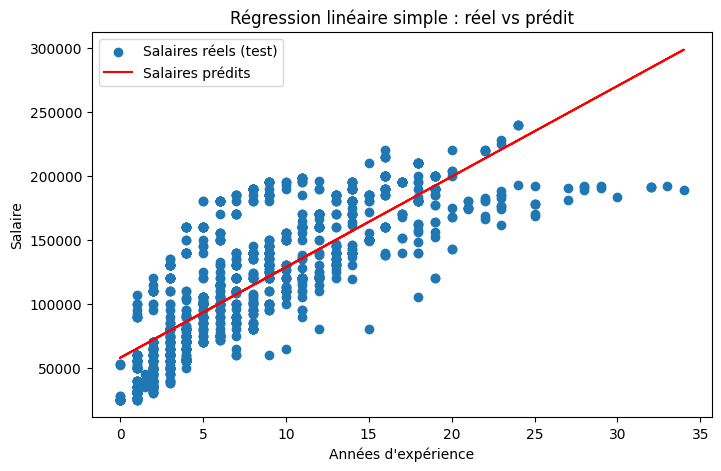

In [26]:
# Taille du graphique (largeur, hauteur en pouces)
plt.figure(figsize=(8, 5))

# Points réels du jeu de test
plt.scatter(X_test, Y_test, label="Salaires réels (test)")

# Droite des salaires prédits par le modèle
plt.plot(X_test, Y_pred, color="r", label="Salaires prédits")

# Habillage du graphique
plt.xlabel("Années d'expérience")
plt.ylabel("Salaire")
plt.title("Régression linéaire simple : réel vs prédit")
plt.legend()
plt.show()